# Binary Classification with a Variational Quantum Classifier

In this notebook, we perform **binary classification** on the Breast Cancer Wisconsin dataset using:

1. A **classical Support Vector Classifier (SVC)**
2. A **Variational Quantum Classifier (VQC)** built with Qiskit Machine Learning

The workflow closely mirrors the structure of an Iris-based quantum classification notebook, but uses a binary dataset instead.


## 1. Imports and Setup

We start by importing all necessary Python, scikit-learn, and Qiskit modules.


In [5]:
import sklearn
import qiskit
import qiskit_machine_learning
from matplotlib import pyplot as plt

# Cosmetic plotting settings
plt.rcParams["figure.figsize"] = (8, 6)


## 2. Load and Inspect the Dataset

We will use the **Breast Cancer Wisconsin** dataset from scikit-learn, a standard binary classification dataset
with labels `malignant` and `benign`.


In [6]:
# Basic numerical / data handling
import pandas as pd

# Sklearn dataset
from sklearn.datasets import load_breast_cancer

# Load Breast Cancer Wisconsin dataset
cancer_data = load_breast_cancer()

# Extract features (X) and labels (y)
X = cancer_data.data      # shape: (n_samples, n_features)
y = cancer_data.target    # shape: (n_samples,)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)
print("Classes:", cancer_data.target_names)
print("Number of features:", len(cancer_data.feature_names))


Feature matrix shape: (569, 30)
Labels shape: (569,)
Classes: ['malignant' 'benign']
Number of features: 30


In [7]:
# Show the first part of the dataset description
print(cancer_data.DESCR[:1000])

# Put data into a pandas DataFrame for easier exploration
df = pd.DataFrame(X, columns=cancer_data.feature_names)
df["target"] = y
df["target_name"] = df["target"].map({i: name for i, name in enumerate(cancer_data.target_names)})

df.head()


.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


## 3. Basic Exploratory Data Analysis (EDA)

We will inspect summary statistics, class balance, and visualize a pair of informative features.


In [8]:
# Summary statistics for each feature
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [9]:
# Class distribution: how many malignant vs benign samples
df["target_name"].value_counts()


target_name
benign       357
malignant    212
Name: count, dtype: int64

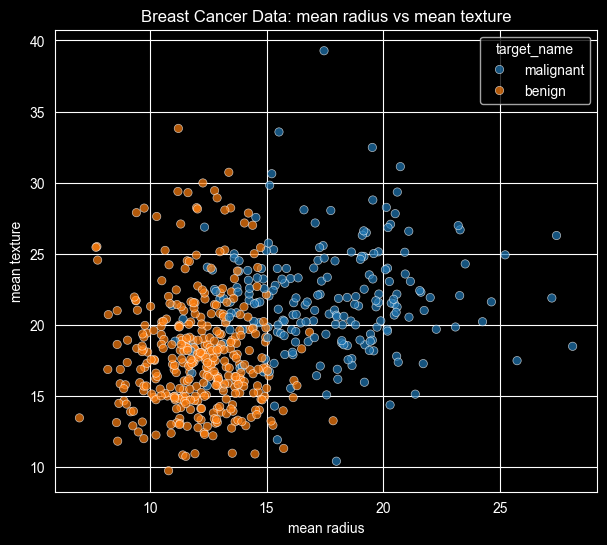

In [10]:
# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize two informative features: mean radius vs mean texture
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df,
    x="mean radius",
    y="mean texture",
    hue="target_name",
    palette="tab10",
    alpha=0.7,
)
plt.title("Breast Cancer Data: mean radius vs mean texture")
plt.show()


## 4. Feature Scaling

We normalize all features to the range [0, 1] using `MinMaxScaler`. This is beneficial for both classical
models and quantum feature maps, which often assume bounded inputs.


In [11]:
# sklearn preprocessing
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Original feature min/max:", X[:, 0].min(), X[:, 0].max())
print("Scaled feature min/max:  ", X_scaled[:, 0].min(), X_scaled[:, 0].max())


Original feature min/max: 6.981 28.11
Scaled feature min/max:   0.0 1.0


## 5. Classical Baseline: SVC on All 30 Features

We first train a classical Support Vector Classifier on the **full 30-dimensional** normalized feature set
to obtain a strong baseline for comparison.


In [12]:
# sklearn train-test split
from sklearn.model_selection import train_test_split
from qiskit_machine_learning.utils import algorithm_globals

# Set global random seed for reproducibility
algorithm_globals.random_seed = 123

# Train-test split on the full 30-dimensional data
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_scaled,
    y,
    train_size=0.8,
    random_state=algorithm_globals.random_seed,
    stratify=y,
)

print("Train shape:", X_train_full.shape)
print("Test shape: ", X_test_full.shape)
print("Train class distribution:\n", pd.Series(y_train).value_counts())
print("Test class distribution:\n", pd.Series(y_test).value_counts())
print("Total samples:", len(y_train) + len(y_test))
print("Total features:", X_train_full.shape[1])
print("Number of classes:", len(cancer_data.target_names))  
print("Classes:", cancer_data.target_names)
print("Number of training samples:", len(y_train))
print("Number of testing samples:", len(y_test))
print("Proportion of malignant samples in training set: {:.2f}%".format(100 * sum(y_train) / len(y_train)))
print("Proportion of malignant samples in testing set: {:.2f}%".format(100 * sum(y_test) / len(y_test)))
print("Overall proportion of malignant samples: {:.2f}%".format(100 * sum(y) / len(y)))
print("Random seed used:", algorithm_globals.random_seed)


Train shape: (455, 30)
Test shape:  (114, 30)
Train class distribution:
 1    285
0    170
Name: count, dtype: int64
Test class distribution:
 1    72
0    42
Name: count, dtype: int64
Total samples: 569
Total features: 30
Number of classes: 2
Classes: ['malignant' 'benign']
Number of training samples: 455
Number of testing samples: 114
Proportion of malignant samples in training set: 62.64%
Proportion of malignant samples in testing set: 63.16%
Overall proportion of malignant samples: 62.74%
Random seed used: 123


In [13]:
# sklearn SVC
from sklearn.svm import SVC

# Classical SVC on 30 features
svc_full = SVC()
svc_full.fit(X_train_full, y_train)

train_score_c_full = svc_full.score(X_train_full, y_train)
test_score_c_full = svc_full.score(X_test_full, y_test)

print(f"Classical SVC (30 features) - Train accuracy: {train_score_c_full:.3f}")
print(f"Classical SVC (30 features) - Test accuracy:  {test_score_c_full:.3f}")


Classical SVC (30 features) - Train accuracy: 0.985
Classical SVC (30 features) - Test accuracy:  0.991


## 6. Dimensionality Reduction with PCA (to 2 Features)

To make the problem suitable for a small quantum circuit, we reduce the 30-dimensional feature space to
just **2 principal components** using PCA. We will later feed these 2D features into both a classical
SVC and a Variational Quantum Classifier (VQC).


In [14]:
# Dimensionality reduction with PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA-reduced shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())
print("PCA components:\n", pca.components_)
print("Singular values:", pca.singular_values_)
print("Mean of original data:", pca.mean_)
print("Number of components:", pca.n_components_)



Original shape: (569, 30)
PCA-reduced shape: (569, 2)
Explained variance ratio: [0.53097689 0.1728349 ]
Total explained variance: 0.7038117901347684
PCA components:
 [[ 2.42675774e-01  9.64786101e-02  2.52550175e-01  2.16494530e-01
   1.09694618e-01  2.40397602e-01  3.01914206e-01  3.22475470e-01
   1.11431911e-01  4.32983397e-02  1.21760615e-01 -3.91796003e-05
   1.18580603e-01  1.03569266e-01 -4.68418094e-03  1.29319789e-01
   6.56807080e-02  1.24746120e-01  1.44902467e-02  4.55013416e-02
   2.59386850e-01  1.13833007e-01  2.60708399e-01  2.05917767e-01
   1.23773566e-01  2.04993413e-01  2.44083623e-01  3.71065064e-01
   9.59229054e-02  9.46335142e-02]
 [-2.61316697e-01 -5.90579194e-02 -2.38590061e-01 -2.31106830e-01
   1.99883951e-01  2.13914883e-01  1.13810591e-01 -8.31206237e-03
   2.11115126e-01  4.06392087e-01 -6.68985209e-02  6.00114468e-02
  -5.14164640e-02 -8.29631528e-02  1.35596439e-01  2.22352585e-01
   1.02792720e-01  1.05646780e-01  1.40474907e-01  1.71995173e-01
  -2.44

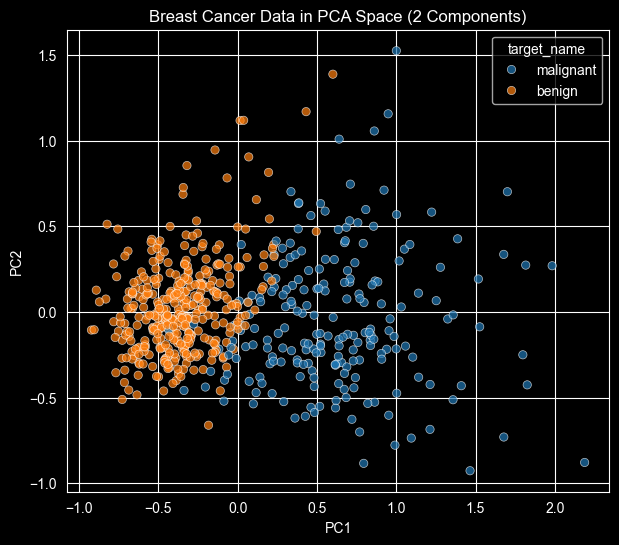

In [15]:
# Visualize the data in 2D PCA space
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["target_name"] = df["target_name"]

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="target_name",
    palette="tab10",
    alpha=0.7,
)
plt.title("Breast Cancer Data in PCA Space (2 Components)")
plt.show()


## 7. Classical SVC on 2D PCA Features

We now train a classical SVC on the 2D PCA-reduced data. This gives us a more fair comparison with
the quantum model that will also operate in a 2-dimensional feature space (2 qubits).


In [16]:
# Train-test split on the 2D PCA features
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_pca,
    y,
    train_size=0.8,
    random_state=algorithm_globals.random_seed,
    stratify=y,
)

print("Train shape (2D):", X_train_2d.shape)
print("Test shape (2D): ", X_test_2d.shape)


Train shape (2D): (455, 2)
Test shape (2D):  (114, 2)


In [17]:
# Classical SVC on 2 PCA features
svc_2d = SVC()
svc_2d.fit(X_train_2d, y_train_2d)

train_score_c_2d = svc_2d.score(X_train_2d, y_train_2d)
test_score_c_2d = svc_2d.score(X_test_2d, y_test_2d)

print(f"Classical SVC (2 PCA features) - Train accuracy: {train_score_c_2d:.3f}")
print(f"Classical SVC (2 PCA features) - Test accuracy:  {test_score_c_2d:.3f}")


Classical SVC (2 PCA features) - Train accuracy: 0.943
Classical SVC (2 PCA features) - Test accuracy:  0.956


## 8. Quantum Model: Variational Quantum Classifier (VQC)

We now construct and train a Variational Quantum Classifier using Qiskit Machine Learning. The model
consists of:

1. A **feature map** (`ZZFeatureMap`) that encodes the 2D PCA features into quantum states.
2. A **variational ansatz** (`RealAmplitudes`) with trainable parameters.
3. A **COBYLA optimizer** to update the parameters.
4. A **StatevectorSampler** to simulate the quantum circuits.


/var/folders/ql/26_rtrxn1wq_csb9smmjm21h0000gn/T/ipykernel_49025/1362167358.py:7: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=num_features, reps=1)


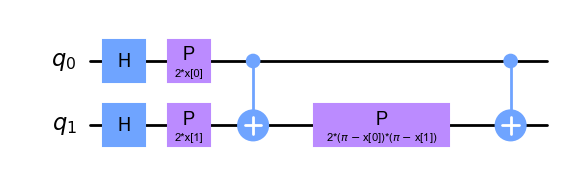

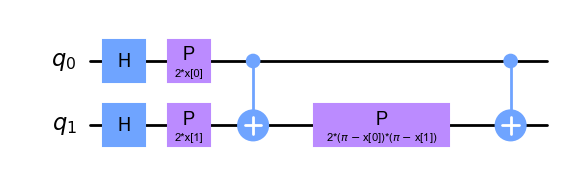

In [18]:
#  Qiskit Machine Learning & quantum circuit building
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes

num_features = X_train_2d.shape[1]  # should be 2

# 1) Feature map: encodes data into quantum states
feature_map = ZZFeatureMap(feature_dimension=num_features, reps=1)
feature_map.decompose().draw(output="mpl", style="clifford", fold=20)


/var/folders/ql/26_rtrxn1wq_csb9smmjm21h0000gn/T/ipykernel_49025/651678950.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=num_features, reps=3)


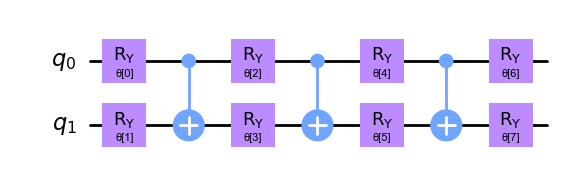

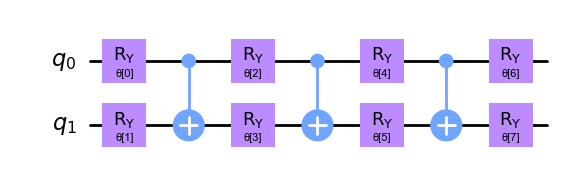

In [19]:
# 2) Ansatz: parameterized circuit with trainable weights
ansatz = RealAmplitudes(num_qubits=num_features, reps=3)
ansatz.decompose().draw(output="mpl", style="clifford", fold=20)


In [20]:
# Optimizer
from qiskit_machine_learning.optimizers import COBYLA

optimizer = COBYLA(maxiter=60)


In [21]:
# Simulation using statevector sampler
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()

In [22]:
from IPython.display import clear_output

objective_func_vals = []
plt.rcParams["figure.figsize"] = (10, 5)

def callback_graph(weights, obj_func_eval):
    """Callback function to visualize the objective value during training."""
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("VQC Training: Objective function vs iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals, marker="o")
    plt.show()


### 8.1 Training the VQC

We now build the VQC object and train it on the 2D PCA features. The callback function will show how the
objective function (loss) evolves over optimization iterations.


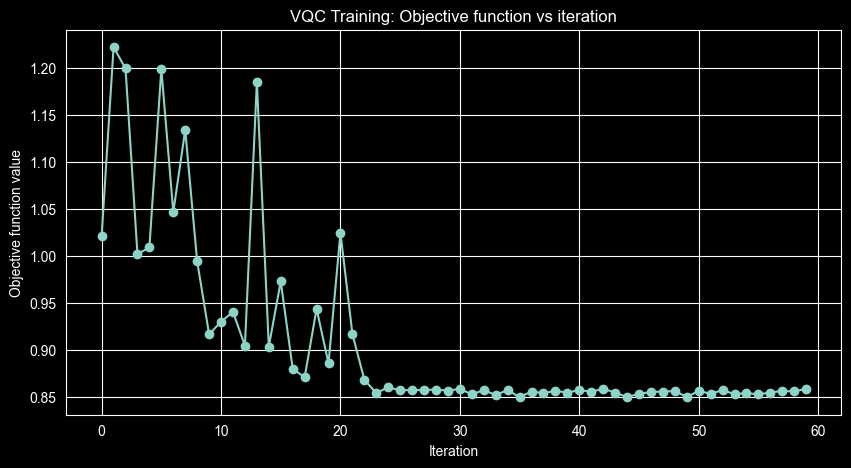

VQC training finished in 47.7 seconds


In [23]:
# Variational Quantum Classifier (VQC)
from qiskit_machine_learning.algorithms.classifiers import VQC
import time

vqc = VQC(
    sampler=sampler,
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback_graph,
)

# Clear history
objective_func_vals = []

start_time = time.time()
vqc.fit(X_train_2d, y_train_2d)
elapsed = time.time() - start_time

print(f"VQC training finished in {elapsed:.1f} seconds")


### 8.2 Evaluating the VQC

We evaluate the trained quantum classifier on both the training and test sets to obtain classification
accuracy, just as we did with the classical models.


In [24]:
train_score_q_2d = vqc.score(X_train_2d, y_train_2d)
test_score_q_2d = vqc.score(X_test_2d, y_test_2d)

print(f"Quantum VQC (2 PCA features) - Train accuracy: {train_score_q_2d:.3f}")
print(f"Quantum VQC (2 PCA features) - Test accuracy:  {test_score_q_2d:.3f}")


Quantum VQC (2 PCA features) - Train accuracy: 0.719
Quantum VQC (2 PCA features) - Test accuracy:  0.675


### 8.3 Improving VQC Performance
We can experiment with different feature maps, ansatz structures, and optimizers to potentially improve
the VQC's performance.


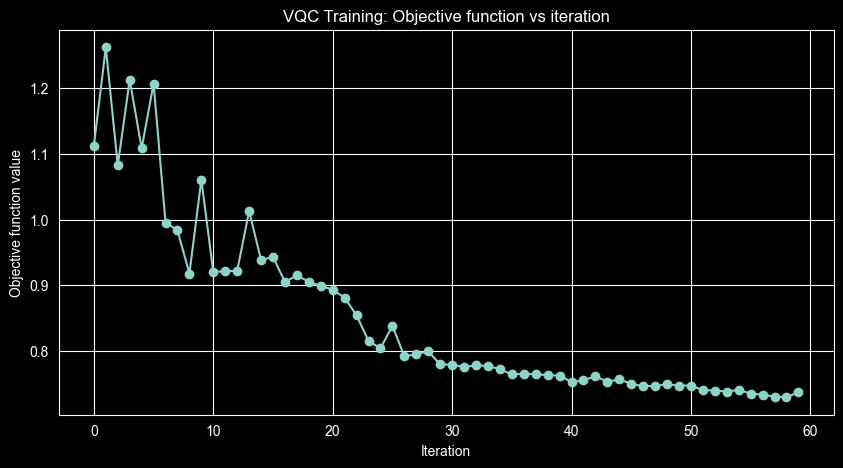

VQC (new ansatz/feature map) training finished in 51.0 seconds
Quantum VQC (new ansatz/feature map) - Train accuracy: 0.767
Quantum VQC (new ansatz/feature map) - Test accuracy:  0.789


In [25]:
from qiskit.circuit.library import PauliFeatureMap, EfficientSU2

# Create new feature map and ansatz
feature_map_new = PauliFeatureMap(feature_dimension=num_features, reps=2)
ansatz_new = EfficientSU2(num_qubits=num_features, reps=2)

vqc_new = VQC(
    sampler=sampler,
    feature_map=feature_map_new,
    ansatz=ansatz_new,
    optimizer=optimizer,
    callback=callback_graph,
)

# Clear history
objective_func_vals = []
start_time = time.time()
vqc_new.fit(X_train_2d, y_train_2d)
elapsed = time.time() - start_time
print(f"VQC (new ansatz/feature map) training finished in {elapsed:.1f} seconds")

train_score_q_new = vqc_new.score(X_train_2d, y_train_2d)
test_score_q_new = vqc_new.score(X_test_2d, y_test_2d)
print(f"Quantum VQC (new ansatz/feature map) - Train accuracy: {train_score_q_new:.3f}")
print(f"Quantum VQC (new ansatz/feature map) - Test accuracy:  {test_score_q_new:.3f}")

## 9. Summary and Comparison

Finally, we compare the performance of:

1. Classical SVC on **30 normalized features**
2. Classical SVC on **2 PCA features**
3. Quantum VQC on **2 PCA features** (ZZFeatureMap + RealAmplitudes ansatz)
4. Quantum VQC on **2 PCA features** (PauliZFeatureMap + EfficientSU2 ansatz)


In [26]:
print("Model                                | Train Acc | Test Acc")
print("-------------------------------------+-----------+----------")
print(f"SVC (30 features)                    | {train_score_c_full:9.3f} | {test_score_c_full:8.3f}")
print(f"SVC (2 PCA features)                 | {train_score_c_2d:9.3f} | {test_score_c_2d:8.3f}")
print(f"VQC (ZZFeatureMap + RealAmplitudes)  | {train_score_q_2d:9.3f} | {test_score_q_2d:8.3f}")
print(f"VQC (PauliZFeatureMap + EfficientSU2)| {train_score_q_new:9.3f} | {test_score_q_new:8.3f}")


Model                                | Train Acc | Test Acc
-------------------------------------+-----------+----------
SVC (30 features)                    |     0.985 |    0.991
SVC (2 PCA features)                 |     0.943 |    0.956
VQC (ZZFeatureMap + RealAmplitudes)  |     0.719 |    0.675
VQC (PauliZFeatureMap + EfficientSU2)|     0.767 |    0.789


## 10. Conclusions

- We used the Breast Cancer Wisconsin dataset to perform a **binary classification** task (benign vs malignant).
- A classical SVC on 30 normalized features provided a strong baseline.
- We used PCA to reduce the data to 2 dimensions, enabling a small, 2-qubit quantum model.
- On the 2D PCA features, we trained:
  - A classical SVC
  - A Variational Quantum Classifier (VQC) using a `ZZFeatureMap` and `RealAmplitudes` ansatz
  - A Variational Quantum Classifier (VQC) using a `PauliZFeatureMap` and `EfficientSU2` ansatz
- The classical SVC outperformed the quantum models, but the VQC still achieved meaningful accuracy
- While the classical model typically achieves the best performance on this dataset, the quantum model
  achieves meaningful accuracy and demonstrates a complete **hybrid quantum–classical ML pipeline**.
